# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print(f"Cantidad de valores nulos: \n {users.isna().sum()} \n")
print(f"Proporción de valores nulos: \n {users.isna().mean()}")


Cantidad de valores nulos: 
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64 

Proporción de valores nulos: 
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(f"Cantidad de valores nulos: \n {usage.isna().sum()} \n")
print(f"Proporción de valores nulos: \n {usage.isna().mean()}")


Cantidad de valores nulos: 
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64 

Proporción de valores nulos: 
 id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  
   Para el dataset users: city tiene un 11.73% y churn_date tiene un 88.35% de valores faltantes
   Para el dataset usage: date tiene un 0.13%, duration un 55.19% y length un 44.74% de valores faltantes
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
   Dataset users:
   - Para city se recomienda inputar con la categoría "unknown" para no perder datos
   - Para churn_date se recomienda ignorar o agregar una columna bandera, ya que esto no es un error y representa a los usuarios activos
   
   Dataset usage:
   - Para date al ser menos del 1% se recomienda eliminar, documentando la acción tomada
   - Para duration y length se recomienda ignorar, ya que el comportamiento normal, cuando el tipo es call la columna duration tendrá un valor y lenth será vacío, cuando el tipo es text pasa lo contrario.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
print(f"Mediana de user_id: {users['user_id'].median()}\n")
print(f"Mediana de age: {users['age'].median()}\n")
users.describe()

Mediana de user_id: 11999.5

Mediana de age: 47.0



,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` está distribuída de manera uniforme y tiene coherencia dado que es una columna autoincremental, no presenta valores anómalos
- La columna `age` tiene valores inválidos ya que no existe una edad negativa.

In [13]:
# explorar columnas numéricas de usage
print(f"Mediana de user_id: {usage['user_id'].median()}\n")
print(f"Mediana de duration: {usage['duration'].median()}\n")
print(f"Mediana de length: {usage['length'].median()}\n")
usage.describe()

Mediana de user_id: 12013.0

Mediana de duration: 3.5

Mediana de length: 50.0



,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` presentan valores normales, ambos son identificadores únicos por lo que la distribución parece estar uniforme
- Las columnas `duration` y `length` presentan outlier, están sesgados hacia la derecha

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene 3531 valores no nulos y 7 valores únicos, de los cuales el valor con más frecuencia es Bogotá, repitiéndose 808 veces lo cual representa un 22.88% del total
- La columna `plan` tiene 4000 valores no nulos y 2 valores únicos, de los cuales Básico representa el 64.87% del total

In [15]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` cuenta con 40000 valores no nulos, 2 valores únicos (text y call) de los cuales text aparece el 55.23% de las veces

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 


**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

  En el dataset users, en la columna age se detectó un valor mínimo de -999, lo cual es una edad imposible y corresponde claramente a un sentinel.
  En el dataset usage, las columnas duration y length, el valor máximo es 120 y 1490 respectivamente, los cuales se alejan demasiado de la mediana que es 3.5 y 50,  dando a entender que son outlier.
  
- ¿Qué acción tomarías?

  Para age en users reemplazaría todos los valores negativos por NaN, así evito que altere cálculos estadísticos como la media, luego crearía una nueva columna a partir de age y reemplazaría los valores NaN con la mediana.

  Para duration y length en usage utilizaría el IQR para calcular el umbral mínimo y máximo (lower y upper) y reemplazaría con ellos los valores que se encuentren fuera de los umbrales.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, al convertir a datetime vemos que ningun valor dio error, es decir todos los valores son fechas válidas, además vemos que existen registros del año 2026, sin embargo solo deberíamos tener registros hasta el 2024.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, se observan registros del año 2024 y también se aprecian valores nan

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

  Si, en `reg_date` de users aparecen registros del 2026, lo cual es imposible dado que el dataset solo registró fechas hasta el 2024
  Y en el caso de `date` en usage no aparecen años imposibles pero si vacíos, lo que significa que se encontraron valores que no se podían convertir a datetime o ya estaban vacíos antes de la conversión (los 50 valores nulos encontrados al explorar el dataset)
  
- ¿Qué harías con ellas?
  Para `reg_date` en users se debe crear una columna sentinel y reemplazar todos los registros con año 2026 con NaN
  Para `date` en usage si corresponde al 0.13% que vimos antes, podemos eliminar las filas
  
  

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = np.where(users['age'] <= 0, age_mediana, users['age'])

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
users['city'].unique()

array(['Medellín', nan, 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali'],
      dtype=object)

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = np.nan
# Verificar cambios
print(users['reg_date'].dt.year.unique())

[2022.   nan 2023. 2024.]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print(f"Total de nulos en duration: {usage['duration'].isna().sum()}\n")
usage[usage['duration'].isna()]['type'].value_counts()

Total de nulos en duration: 22076



text    22076
Name: type, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
print(f"Total de nulos en length: {usage['length'].isna().sum()}\n")
usage[usage['length'].isna()]['type'].value_counts()

Total de nulos en length: 17896



call    17896
Name: type, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los valores de duration y length dependen directamente de la columna type, cuando type es una llamada (call) se registra la duración de la llamada en `duration`, en cambio cuando type es un chat (text) la longitud del mensaje se registra en `length`, esto explica que la ausencia de valores coincida al 100% con el tipo de servicio. Al confirmarse este comportamiento se decide dejarlos como nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
  'is_text': 'cant_mensajes',
  'is_call': 'cant_llamadas',
  'duration': 'cant_minutos_llamada',
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

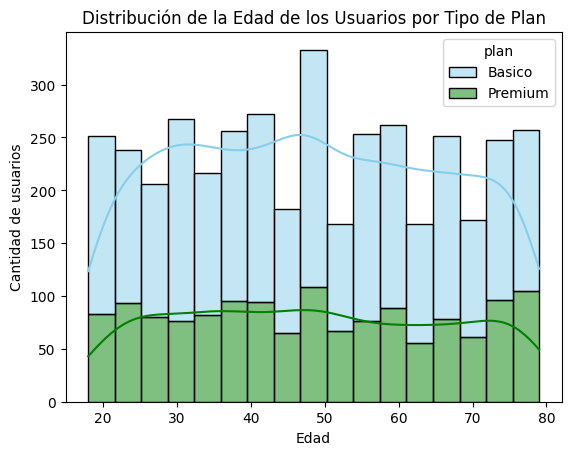

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True, multiple='stack')
plt.title('Distribución de la Edad de los Usuarios por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: Edad(age)
- Distribución: tiene una distribución uniforme, las barras se mantienen relativamente estables en todo el rango, lo que significa que no hay un sesgo hacia la derecha o izquierda

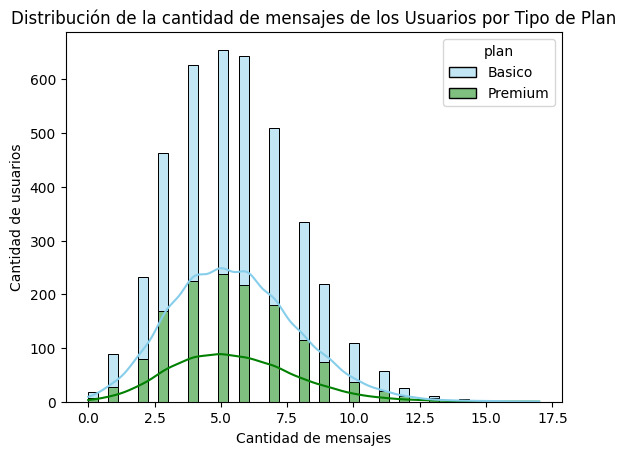

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True, multiple='stack')
plt.title('Distribución de la cantidad de mensajes de los Usuarios por Tipo de Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()



💡Insights: Cantidad de mensajes
- Distribución: Tiene una distribución sesgada hacia la derecha
- Dentro del plan Premiun hay mayor proporción de usuarios concentrados en el rango de 4 a 6 mensajes
- Dentro del plan básico hay un comportamiento similar al premiunm sin embargo muestra una caída más pronunciada a partir de los 8 mensajes

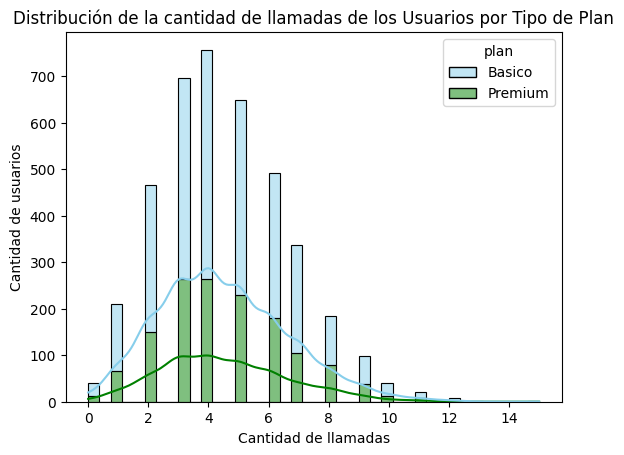

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True, multiple='stack')
plt.title('Distribución de la cantidad de llamadas de los Usuarios por Tipo de Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()




💡Insights: cantidad de llamadas
- Distribución: Tiene una distribución sesgada hacia la derecha
- Dentro del plan Premiun hay mayor proporción de usuarios concentrados en el rango de 3 a 4 llamadas
- Dentro del plan básico la mayor concentracipon está en 4 llamadas por usuario

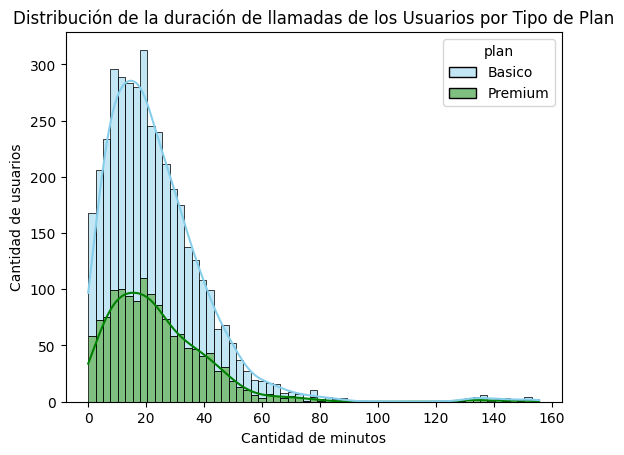

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True, multiple='stack')
plt.title('Distribución de la duración de llamadas de los Usuarios por Tipo de Plan')
plt.xlabel('Cantidad de minutos')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: Duración de llamadas
- Distribución: Tiene una distribución sesgada hacia la derecha muy marcada, esto confirma presencia de outliers 
- Dentro del plan Premiun tiene una mayor concentración entre 10 y 25 minutos, luego muestra una pendiente de descenso menos empinada que el plan básico. 
- Dentro del plan básico la concentración está en el rango de 10 a 20 minutos, descendiendo de manera drástica y muy rápida pasando los 35 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.


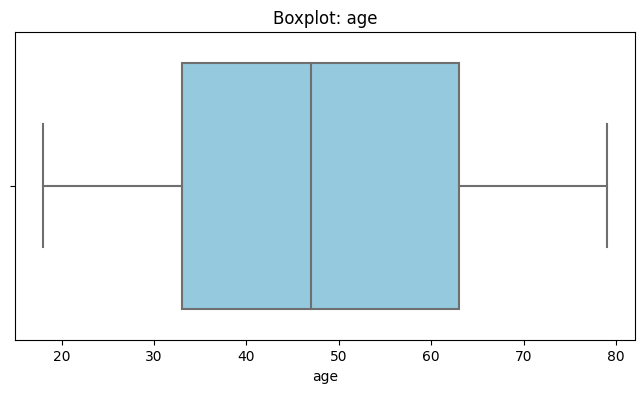

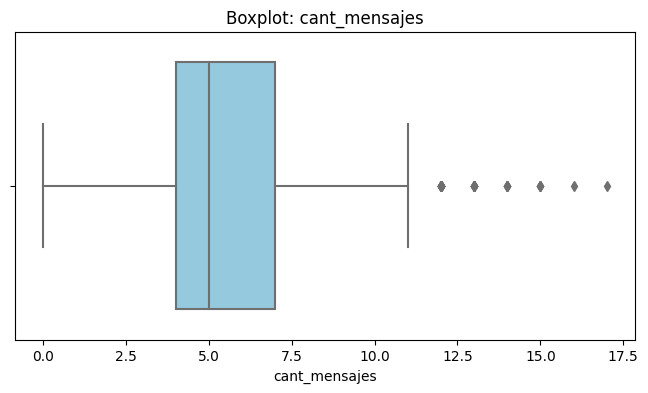

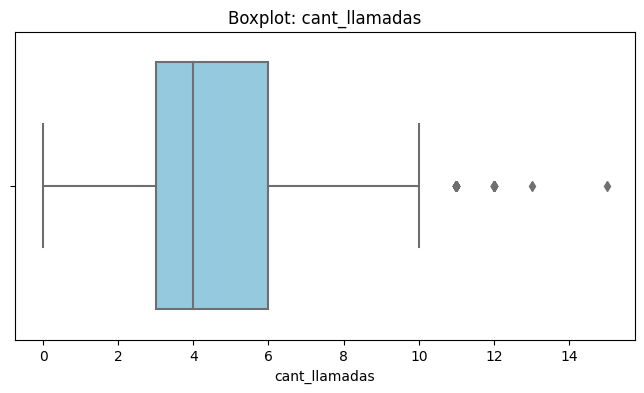

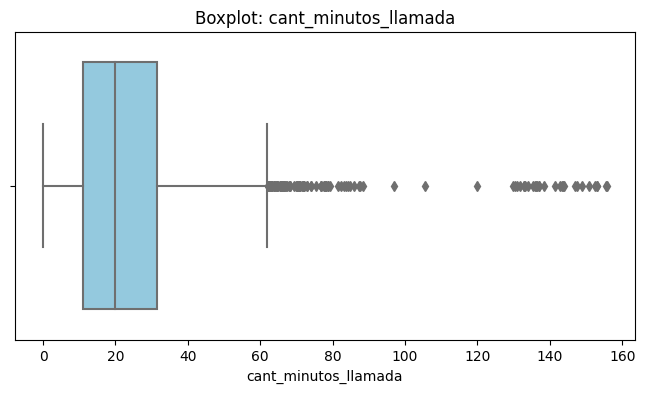

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()
    

💡Insights: 
- Age: No presenta outliers, la distribución se mantiene dentro de los bigotes del gráfico
- cant_mensajes: Si presenta outliers, se observan valores atípicos concentrados en el extremo superior derecho
- cant_llamadas: Si presenta outliers, se observan valores atípicos concentrados en el extremo superior derecho
- cant_minutos_llamada: Si presenta outliers, se observan una alta densidad de valores atípicos concentrados de manera extendida hacia el extremo superior derecho

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = IQR + 1.5*IQR

    print(f"=====Columna {col}=====\n")
    print(f"Límite superior: {limite_superior}\n")
    print(f"Cantidad de outliers detectados: {(user_profile[col] > limite_superior).sum()}\n")



=====Columna cant_mensajes=====

Límite superior: 7.5

Cantidad de outliers detectados: 765

=====Columna cant_llamadas=====

Límite superior: 7.5

Cantidad de outliers detectados: 353

=====Columna cant_minutos_llamada=====

Límite superior: 50.737500000000004

Cantidad de outliers detectados: 222



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  Mantener los outliers. IQR establece un límite de 7.5 y 765 registros se encuentran fuera de este límite, lo que representa el 19.1% de los datos de mensajes. Dado que los valores máximos reales son razonables (17 mensajes como máximo absoluto), no corresponden a errores de carga o bugs, sino a usuarios con un uso legítimamente más activo. Modificarlos eliminaría variabilidad real e importante del negocio.
  
- cant_llamadas: mantener o no outliers, porqué?
    Mantener los outliers. IQR establece un límite de 7.5 y 353 registros se encuentran fuera de este límite (8.8%) el valor máximo es de 15 así que el comportamiento (al igual que en los mensajes) corresponde a usuarios más activos y es un comportamiento real.
  
- cant_minutos_llamada: mantener o no outliers, porqué?
    Mantener los outliers. Pero aplicando el límite superior, dado que el IQR es de 50.7 minutos y 222 valores (5.5%) se encuentran fuera de este rango, es recomendable limitar su valor para que no distorcione medidas estadísticas como la media.
  

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),   # Condición Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)  # Condición Uso medio
]

resultados = ['Bajo uso', 'Uso medio']
user_profile['grupo_uso'] = np.select(condiciones, resultados, default='Alto uso')


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
condiciones = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

resultados = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, resultados, default='Adulto Mayor')

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

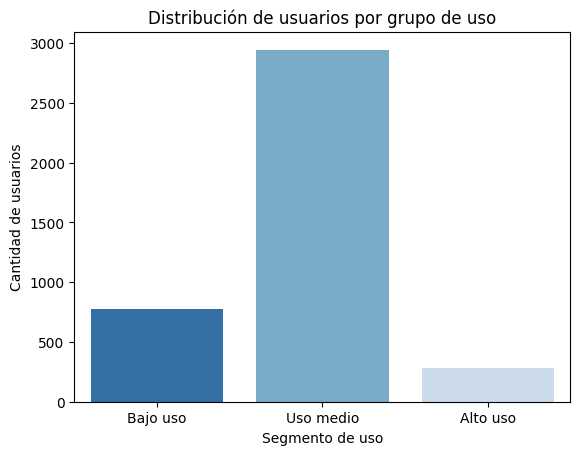

In [41]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette='Blues_r', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Segmento de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

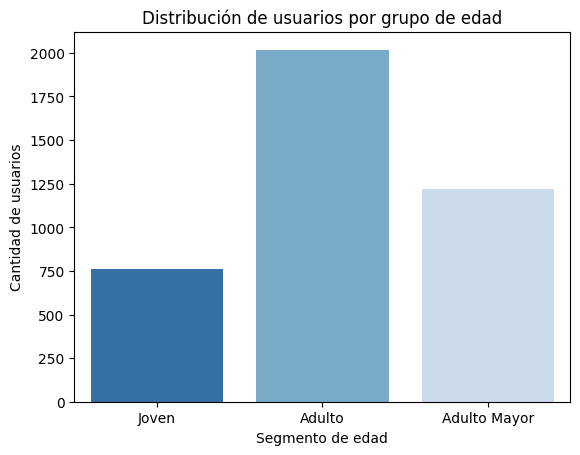

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='Blues_r', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Segmento de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Al inicio del proyecto, los dataset presentaban anomalías estructurales, valores nulos y registros corruptos que requerían limpieza.
- Valores sentinels en edad(`age`), se detectó valores negativos (-999) que representaba una cantidad menor al 1% de los datos.
- Registros corruptos en ciudad(`city`), un total de 469 filas (11.73% de los datos) presentaban caracteres "?" en lugar del nombre de la ciudad.


🔍 **Segmentos por Edad**
- Joven (Menores de 30 años): Representa el segmento más pequeño de la base (aproximadamente 750 usuarios). Muestra un comportamiento de adopción tecnológica estándar.
- Adulto (Entre 30 y 60 años): Es el núcleo principal de la empresa, superando los 2,000 usuarios. Este grupo estabiliza el consumo general de ConnectaTel.
- Adulto Mayor (Mayores de 60 años): Un segmento sumamente robusto con más de 1,200 usuarios. 


📊 **Segmentos por Nivel de Uso**
- Bajo Uso (Llamadas < 5 y Mensajes < 5): Alrededor de 800 usuarios que utilizan la línea para necesidades estrictamente puntuales o de emergencia.
- Uso Medio (Llamadas < 10 y Mensajes < 10): El segmento dominante del negocio, con casi 3,000 usuarios. Son el cliente promedio ideal: su consumo de minutos tiene un pico máximo concentrado entre los 10 y 25 minutos por llamada.
- Alto Uso (El resto de casos): Un grupo exclusivo de aproximadamente 300 usuarios. Son consumidores intensivos que superan los umbrales estándar de la red.


➡️ Esto sugiere que...

- Los segmentos más valiosos para ConnectaTel son el segmento de Adultos (30-60 años) en el ámbito demográfico, y el segmento de Uso Medio en el ámbito operativo. Los Adultos representan el mayor volumen de facturación recurrente, mientras que el perfil de Uso Medio genera un tráfico masivo pero predecible, lo que permite una planificación óptima de la infraestructura de red sin saturar los canales de comunicación.
- Los patrones de uso extremo (outliers) identificados mediante el método IQR muestran que en cant_mensajes (límite 7.5, máx 17) y cant_llamadas (límite 7.5, máx 15), los valores altos representan simplemente un comportamiento humano orgánico de usuarios hiperactivos comerciales, por lo que se mantuvieron intactos para no eliminar la variabilidad real del negocio.
- En cant_minutos_llamada, el límite IQR de 50.7 minutos fue ampliamente superado por 222 usuarios (5.5% del total) que alcanzaron picos extremos de hasta 155.69 minutos. Para el negocio, esto implica la presencia de cuentas corporativas o un consumo desmedido que sesga las métricas de media de la compañía.


💡 **Recomendaciones**
- Tratamiento de Consumo Extremo (Capping en Minutos): Aplicar una regla de corte (capping) en la base de datos para fijar un tope analítico en 50.74 minutos para las llamadas del plan Básico, evitando que consumos atípicos individuales distorsionen los reportes financieros y comerciales.
- Lanzamiento de un Plan "Connecta Pro / Ejecutivo": Diseñar un tercer plan orientado exclusivamente al segmento de Alto Uso. Si el plan Premium actual ofrece 600 minutos por USD 25, este nuevo plan podría ofrecer minutos ilimitados con una tarifa plana de USD 35 a USD 40, capturando el valor marginal de ese 5.5% de usuarios extremos.
- Fidelización del Segmento Adulto Mayor: Dado que el volumen de mayores de 60 años es sumamente alto (más de 1,200 usuarios) y su distribución de consumo es estable y controlada, se recomienda diseñar una campaña de marketing específica para ellos ("Plan Conectados"), ofreciendo tarifas preferenciales en el plan Básico a cambio de contratos de permanencia, asegurando un flujo de caja predecible con un bajo impacto de tráfico en la red.